# Morphology analysis of distributions

___

The statistical properties of a phase or point distribution can be studied beyond its reciprocal space by analysing the shapes of each detected object/void. This is possible with the `Morphology` class available in the Statistics module.

In this notebook, we shall generate a point distribution and use it to understand the morphological features of various phase distributions that can be constructed from it. Since this class is only currently available for 2D distributions, the analysis here is also restricted to 2D.

In [1]:
import numpy as np
import tostada as tost
import matplotlib.pyplot as plt

GPU detected. Using CUDA.
GPU detected. Using CUDA.
Using MPI version 4.1, 1 processes
GPU detected. Using CUDA
Using JAX devices: [CudaDevice(id=0)]


E0611 19:50:10.639370 1405981 cuda_context.cc:141] The primary context is active and has a different flag set (128) than the desired flag set (0).


In [2]:
process = tost.Pointprocess(BoxSize=8,
                            diameter=0.2,
                            ax=0.3)
points = process.RandomSequentialAdsorption()

Estimated particles to be deposited=711 with mean inter-particle distance=0.3
number of experiments:8528000): |------------------------------| 0.9% Current FF=11.109 of 11.111


Since morphology is a property of the underlying distribution, it is available in both `PointDistribution` and `PhaseDistribution` using a `compute_morphology` method. First, let us create a trivalent network from the above point distribution.

In [3]:
phase = points.Phaseobject_trivalent(resolution = 0.01, # resolution of the image (in microns)
                                    rad = 5 # radius of the walls (in pixels)
                                    )

Volume fraction of generated phase = 0.5489486456536071 with resolution = 0.009987515605493134


<Axes: title={'center': 'Phase Distribution'}, xlabel='X ($\\mathrm{\\mu}$m)', ylabel='Z ($\\mathrm{\\mu}$m)'>

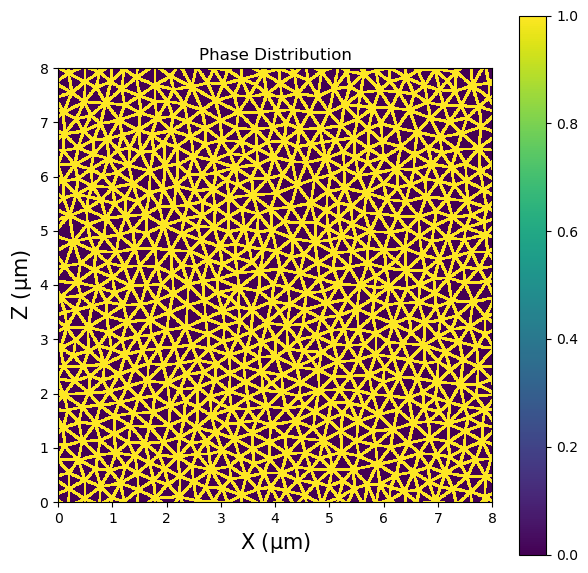

In [4]:
fig = tost.Visualize(phase)
fig.plot_distribution()

Since we want to analyze the pore structures, we must invert the image and make them the objects. This can be done using `invert_phases()`.

In [5]:
phase.invert_phases()

In [6]:
mor = phase.compute_morphology()

Morphology object created


/home/prerak/tostada/src/tostada/Statistics.py:413: RuntimeWarning: invalid value encountered in divide
  thetas[i,:] = np.nan_to_num(np.angle(psi_)/s)


This creates a `Morphology` object. The phase distribution above is used to detect polygons (arbitrarily shaped objects/voids) and their geometrical features. The phase distribution itself is also accessible within this class. The detected polygons can be visualized using `tostada.Visualize.plot_detected_polygons()`

<Axes: xlabel='X ($\\mathrm{\\mu}$m)', ylabel='Y ($\\mathrm{\\mu}$m)'>

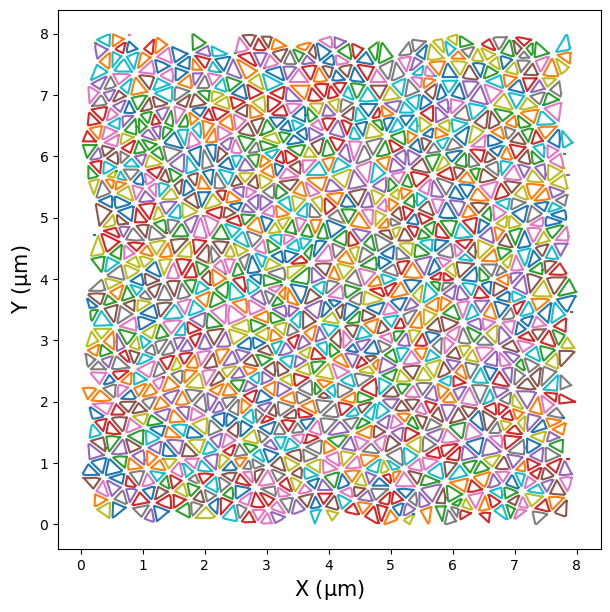

In [7]:
fig = tost.Visualize(phase) # inverted phase here

fig.plot_detected_polygons()

Once initialized, the `Morphology` class generates Minkowski structure metrics for the system, accesible via `Morphology.psi`. For each detected polygon, it contains m values like $q_1,q_2,...q_m$ that characterize the local m-fold symmetry. Since the generated distribution is trivalent in nature, it should have high $q_3$ (and also $q_6$) but lower $q\neq3$.

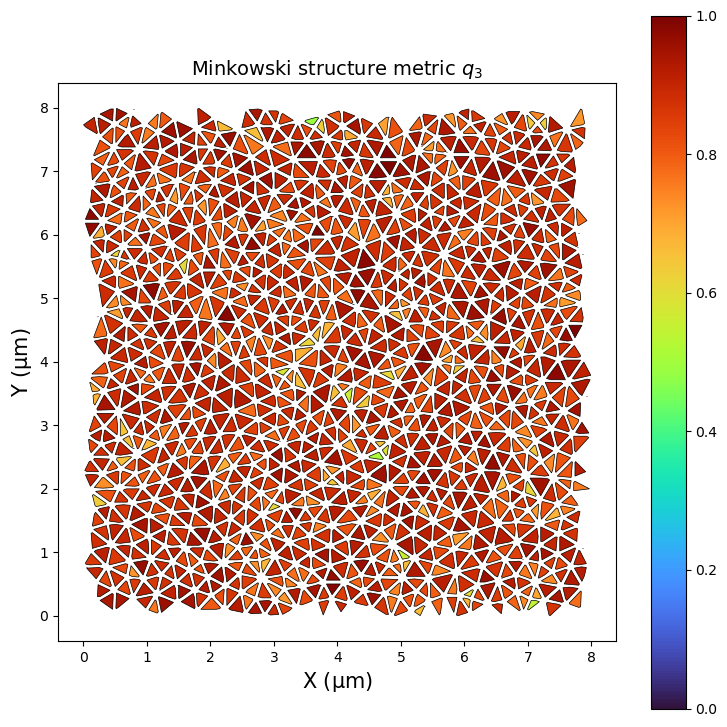

In [8]:
fig = tost.Visualize(phase)
ax=fig.plot_structure_metric(s=3, # order of the Minkowski structure metric to be plotted for each polygon
                             skipind=0 #skips the first n polygons (simulation box and spurious edge(s))
                             )

<Axes: title={'center': 'Minkowski structure metric $q_4$'}, xlabel='X ($\\mathrm{\\mu}$m)', ylabel='Y ($\\mathrm{\\mathrm{\\mu}}$m)'>

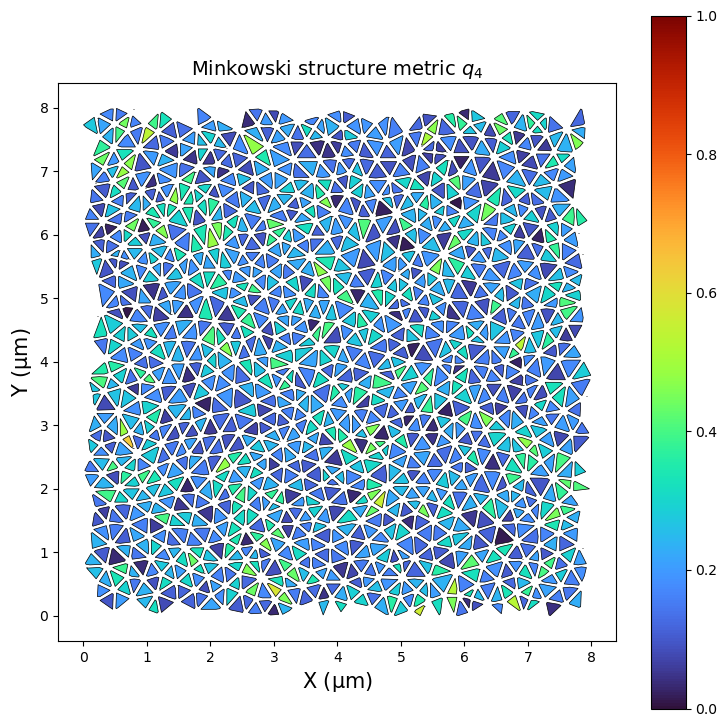

In [9]:
fig.plot_structure_metric(s=4,
                          skipind=0)

It is also possible to individually or collectively plot the detected polygons. This can be done using `Morphology.draw_polygon()`.

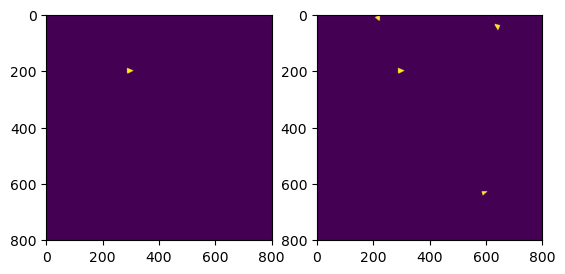

In [52]:
Img = mor.draw_polygon(shape=phase.BoxSize,polygon_ind=366,resolution=phase.resolution,shift_vec=[0,0])
Img2 = mor.draw_polygon(shape=phase.BoxSize,polygon_ind=[1199,366,58,3],resolution=phase.resolution,shift_vec=[0,0])

fig = plt.figure()
ax = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)
ax.imshow(Img)
ax2.imshow(Img2)

Since these images are at the same resolution as the original image, one can create a new `PhaseDistribution` and analyze the shapes separately.

(801, 801) (801, 801)


[<Axes: title={'center': 'Reciprocal Space, Spectral density $\\tilde{X}(\\mathbf{q})$'}, xlabel='$q_{x}$ ($\\mathrm{\\mu}$m$^{-1}$)', ylabel='$q_{y}$ ($\\mathrm{\\mu}$m$^{-1}$)'>,
 <Axes: xlabel='|q| ($\\mathrm{\\mu}$m$^{-1}$)', ylabel='$\\tilde{X}(|\\mathbf{q}|)$'>]

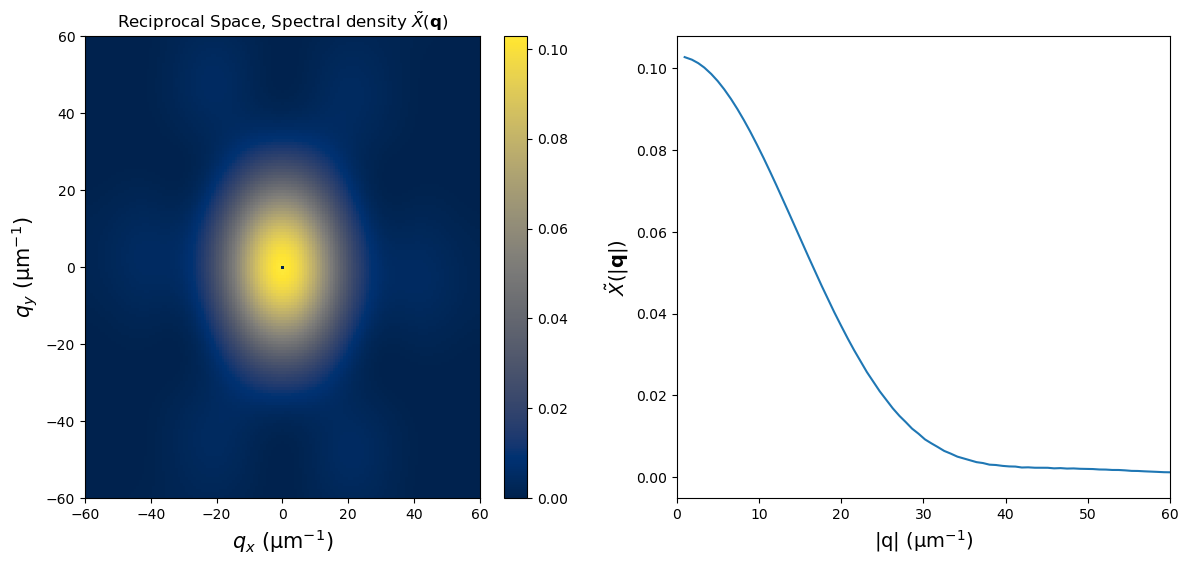

In [ ]:
object_phase = tost.PhaseDistribution(Img,phase.resolution)
fig = tost.Visualize(object_phase)
fig.plot_reciprocal_space(vmax=None)

(801, 801) (801, 801)


[<Axes: title={'center': 'Reciprocal Space, Spectral density $\\tilde{X}(\\mathbf{q})$'}, xlabel='$q_{x}$ ($\\mathrm{\\mu}$m$^{-1}$)', ylabel='$q_{y}$ ($\\mathrm{\\mu}$m$^{-1}$)'>,
 <Axes: xlabel='|q| ($\\mathrm{\\mu}$m$^{-1}$)', ylabel='$\\tilde{X}(|\\mathbf{q}|)$'>]

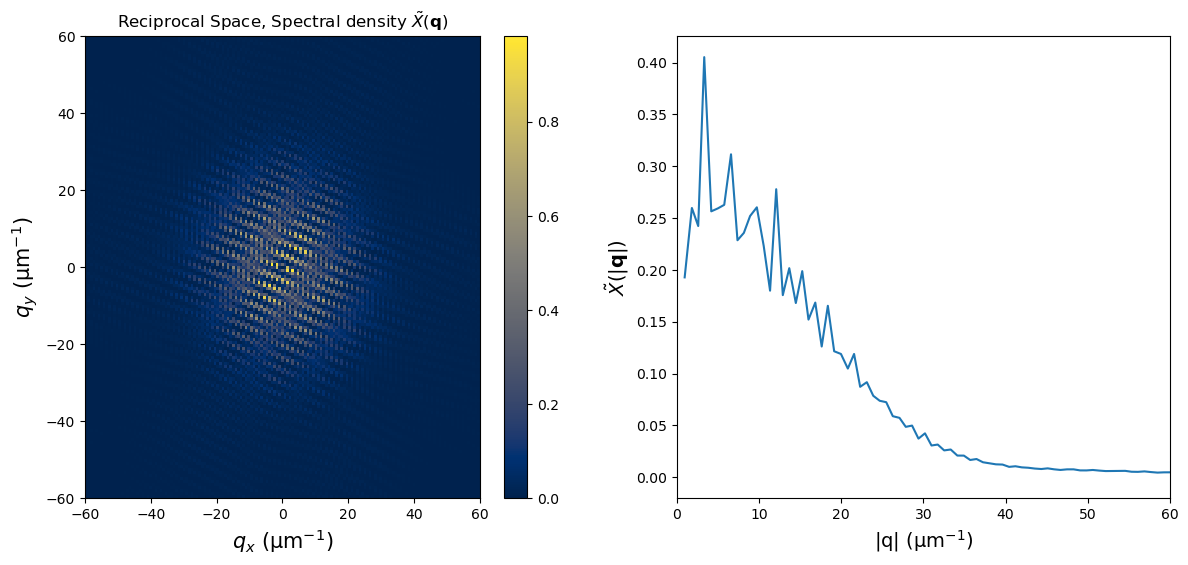

In [53]:
object_phase = tost.PhaseDistribution(Img2,phase.resolution)
fig = tost.Visualize(object_phase)
fig.plot_reciprocal_space(vmax=None)

These visualizations can be summarized using `Morphology.get_morphology_stats()` method that computes the mean and standard deviation of each $q_m$.

Mean interfacial length = 0.6012850792340898+/-0.19228911832296142


(0.0, 1.0)

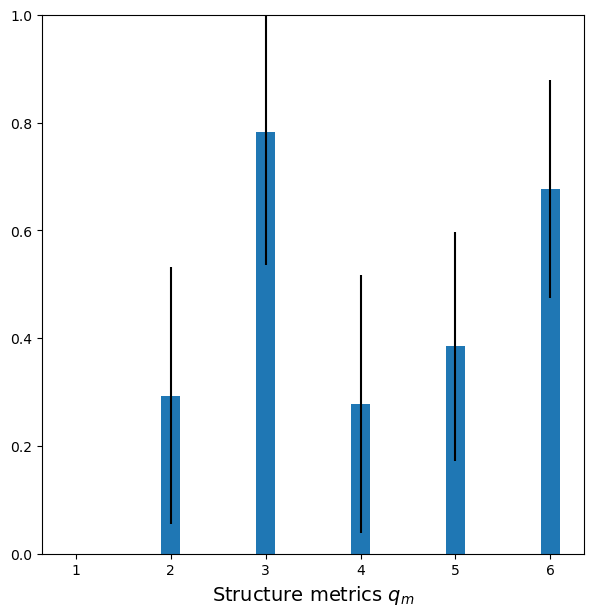

In [55]:
ax = phase.morphology.get_morphology_stats()
plt.ylim(0,1)

The statistics confirm that $q_3$ is indeed higher than others indicating 3-fold symmetry in the distribution. 

___

Now, let us create a circular pore system and analyze the same properties.

In [61]:
phase2 = points.Phaseobject(dx = 0.0075) 
phase2.invert_phases()
Mor = phase2.compute_morphology()

Morphology object created


<Axes: xlabel='X ($\\mathrm{\\mu}$m)', ylabel='Y ($\\mathrm{\\mu}$m)'>

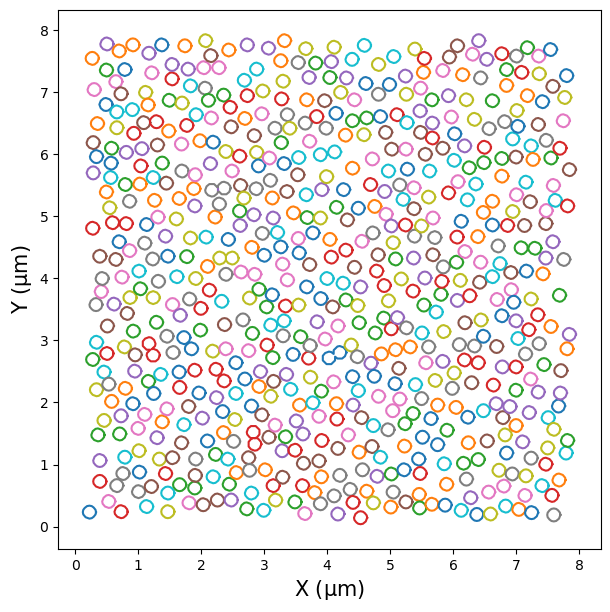

In [59]:
fig = tost.Visualize(phase2)

fig.plot_detected_polygons()

Mean interfacial length = 0.6453873446790681+/-0.06024755390694764


(0.0, 1.0)

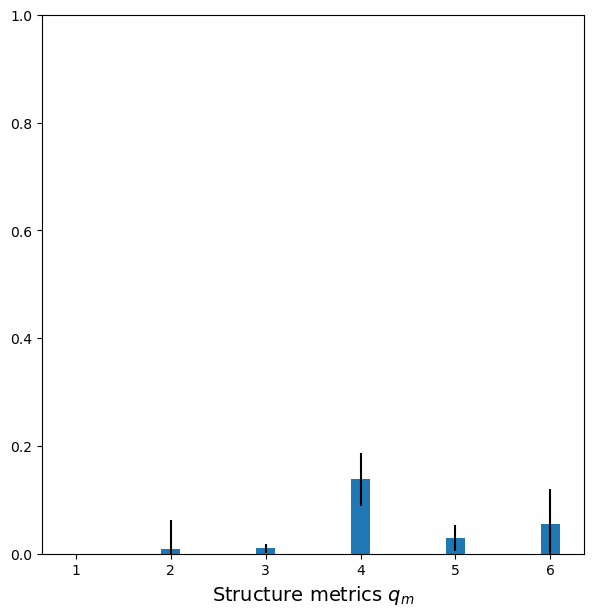

In [62]:
Mor.get_morphology_stats()
plt.ylim(0,1)

For circular objects, the only non-negative $q_m$ should be $q_1$ indicating closed polygons. However, $q_4$ appears to be slightly high. This is because circular objects are approximated by n-sided polygons and also because the computational domain choosen here is rather small for quick illustrations. For larger domains, this approaches zero too.

The un-normalized zeroth coefficient $\psi_1$ gives the perimeter of a given interface. Tostada saves this value for each polygon in `psi[:,0]` and so the mean statistics gives the mean perimeter of the objects/voids. For identical circles, this can be easily verified as $c = \pi d$.

In [65]:
Mor.mean_stats[0]/np.pi, points.diameter

(np.float64(0.20543317222925306), 0.2)

TOSTADA uses [scikit-image](https://scikit-image.org/) to do advanced shape analysis. By creating a morphology object, one gets access to `RegionProperties` of each detected object. This is accesible via `Morphology.properties`. 

We use the `Morphology.get_local_properties()` to access some quick properties. Let us use this to measure the area of each detected circle. For our chosen diameter of $d=0.2\mathrm{\mu m}$, this is $A=\pi d^2 = \pi/100$.

In [82]:
areas = Mor.get_local_properties('area') # other possible options are : 'area', 'euler_number', 'orientation', 'eccentricity', 'perimeter'

Since the detected happened on pixels, the areas here are also in pixels. 

In [83]:
true_areas = areas*phase2.resolution**2
print (np.mean(true_areas),np.std(true_areas))

0.030306355932203377 0.004007979410618197


In [84]:
np.pi/100

0.031415926535897934

(array([637.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  12.]),
 array([0.02975625, 0.03273188, 0.0357075 , 0.03868312, 0.04165875,
        0.04463437, 0.04761   , 0.05058562, 0.05356125, 0.05653688,
        0.0595125 ]),
 <BarContainer object of 10 artists>)

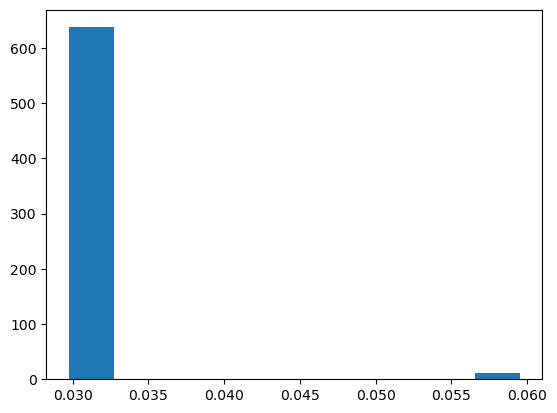

In [85]:
plt.hist(true_areas)

It is worth noting that this is not exactly equal only because of the low resolution (with respect to the diameter) used in creating the phase distribution. For high resolutions, this should closely match the input diameter.

___

Now, let us consider two different kinds of phase distribution. The first one is the Voronoi type distribution where the points are first tesselated using Voronoi networks and the network edges are dilated to yield a particular volume fraction. Next is a Centroidal Volume tesselation where before forming the voronoi tesselation, the point distribution is first relaxed using Llyod's algorithm (essentially points are slightly shifted until the polygon's center-of-mass roughly cooincides with the shifted points.)

In [3]:
phase3 = points.Phaseobject_voronoi(resolution = 0.01, rad = 6)
phase3.invert_phases()
Mor1 = phase3.compute_morphology()

Volume fraction of generated phase = 0.4203375618180146 with resolution = 0.009987515605493134
Morphology object created


/home/prerak/tostada/src/tostada/Statistics.py:413: RuntimeWarning: invalid value encountered in divide
  thetas[i,:] = np.nan_to_num(np.angle(psi_)/s)


<Axes: xlabel='X ($\\mathrm{\\mu}$m)', ylabel='Y ($\\mathrm{\\mu}$m)'>

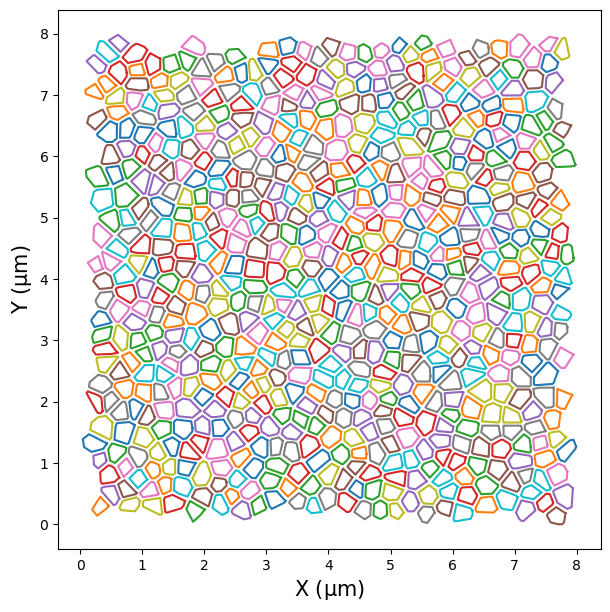

In [4]:
fig = tost.Visualize(phase3)
fig.plot_detected_polygons()

In [6]:
new_pts = points.lloyd_relaxation()

/home/prerak/tostada/src/tostada/Statistics.py:413: RuntimeWarning: invalid value encountered in divide
  thetas[i,:] = np.nan_to_num(np.angle(psi_)/s)


Morphology object created
Morphology object created
Morphology object created
Morphology object created
Morphology object created
Morphology object created
Morphology object created
Morphology object created
Morphology object created
Morphology object created


In [7]:
new_points = tost.PointDistribution(new_pts,points.diameter,points.BoxSize)
phase4 = new_points.Phaseobject_voronoi(resolution = 0.01, rad = 6)
phase4.invert_phases()
Mor2 = phase4.compute_morphology()

Volume fraction of generated phase = 0.40989181750028447 with resolution = 0.009987515605493134
Morphology object created


/home/prerak/tostada/src/tostada/Statistics.py:413: RuntimeWarning: invalid value encountered in divide
  thetas[i,:] = np.nan_to_num(np.angle(psi_)/s)


<Axes: title={'center': 'Minkowski structure metric $q_6$'}, xlabel='X ($\\mathrm{\\mu}$m)', ylabel='Y ($\\mathrm{\\mathrm{\\mu}}$m)'>

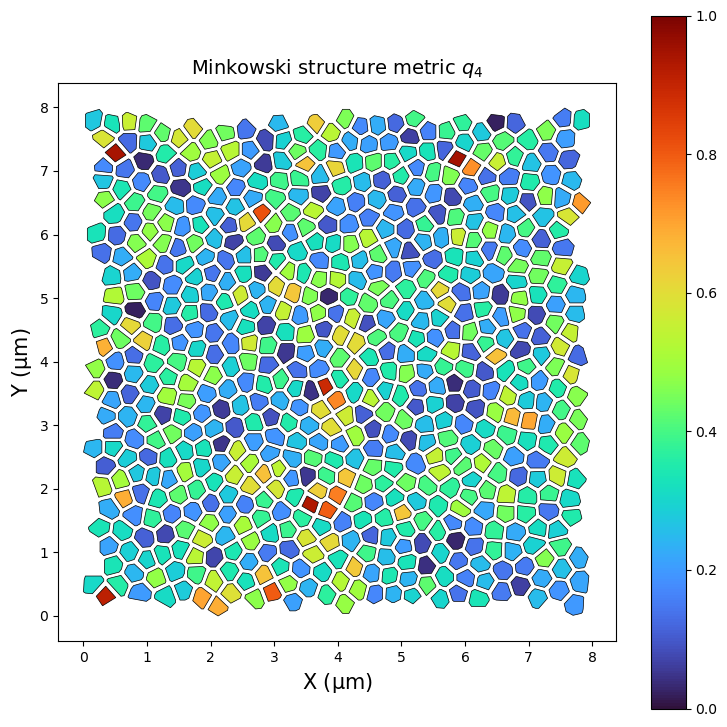

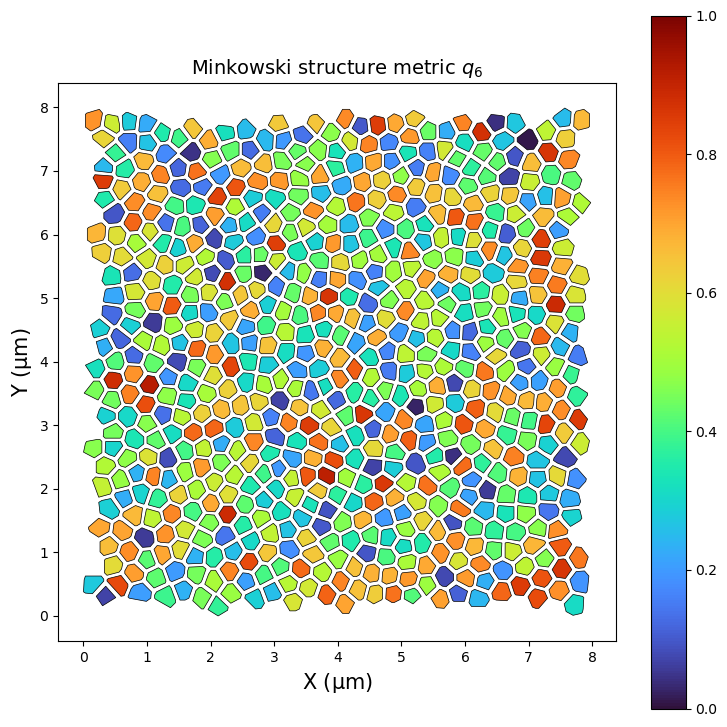

In [12]:
fig = tost.Visualize(phase4)
fig.plot_structure_metric(s=4,
                          skipind=0)
fig.plot_structure_metric(s=6,
                          skipind=0)

(801, 801) (801, 801)


[<Axes: title={'center': 'Reciprocal Space, Spectral density $\\tilde{X}(\\mathbf{q})$'}, xlabel='$q_{x}$ ($\\mathrm{\\mu}$m$^{-1}$)', ylabel='$q_{y}$ ($\\mathrm{\\mu}$m$^{-1}$)'>,
 <Axes: xlabel='|q| ($\\mathrm{\\mu}$m$^{-1}$)', ylabel='$\\tilde{X}(|\\mathbf{q}|)$'>]

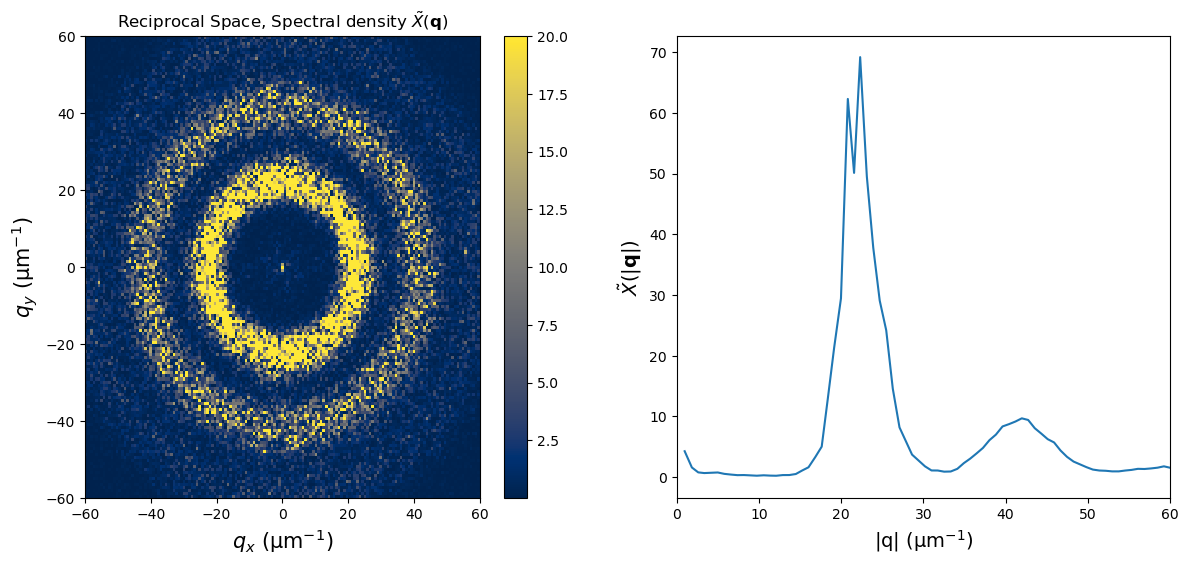

In [14]:
fig.plot_reciprocal_space()

Mean interfacial length = 0.915003447828383+/-0.09471920342190347
Mean interfacial length = 0.8946660128296778+/-0.046958389160967555


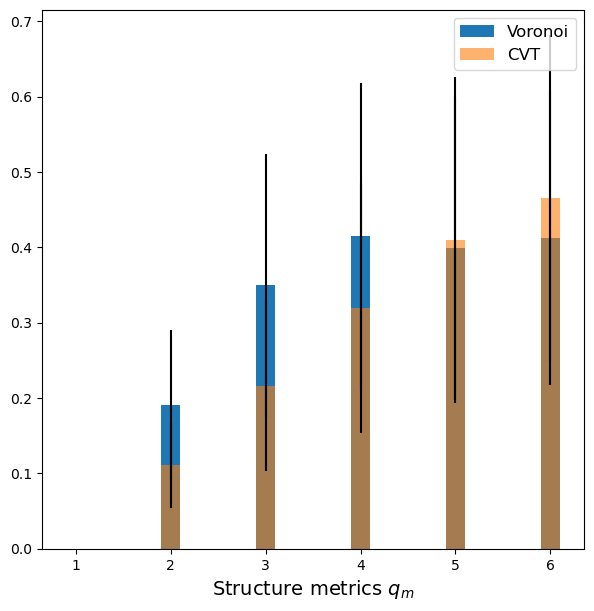

In [13]:
ax = Mor1.get_morphology_stats(label='Voronoi')
Mor2.get_morphology_stats(ax=ax,label='CVT',alpha=0.6)
ax.legend(fontsize=12)

It can clearly be seen that relaxing the point distribution before tesselation increases the "hexatic" order in the system while simultaneously decreasing $q_{m}$.